In [1]:
import numpy as np
import matplotlib.pyplot as plt
from itertools import product
import h5py 
import os
import pandas as pd
import matplotlib.colors as mcolors


In [2]:
dirpath = '/Users/kimchm/Documents/KimNiNature2024/MatConverted2Python/' 
# sessName = 'BAYLORJH035_FOV1_2021_12_09_2022_02_15.npy'
# sessName = 'BAYLORJH123_FOV1_2022_10_01_2022_11_07'
sessName = 'BAYLORJH134_FOV13_2023_04_29_2023_06_01'
# sessName = 'BAYLORJH118_FOV5_2022_10_30_2022_12_01'
fileName = sessName + '.npy'
# CD_0_BAYLORJH123_FOV1_2022_10_01_2022_11_07
filepath = dirpath + fileName

In [3]:
data = np.load(filepath, allow_pickle=True)
opto_sess1 = data['deconvolved'][0]
opto_sess2 = data['deconvolved'][1]


In [33]:
tsample   = 1.57
tdelay    = 2.87
tresponse = 4.17
dt        = 1/6
ntimestep = 47
tvec      = dt * np.arange(ntimestep)
tix_sample   = np.where(tvec > tsample)[0][0]
tix_delay    = np.where(tvec > tdelay)[0][0]
tix_response = np.where(tvec > tresponse)[0][0]

ncat, ncell = opto_sess1.shape
lickright = 0
lickleft  = 1

In [5]:
# concatenate all trials into one array
ntrials_1R = opto_sess1[lickright,0].shape[1]
ntrials_1L = opto_sess1[lickleft,0].shape[1]
ntrials_2R = opto_sess2[lickright,0].shape[1]
ntrials_2L = opto_sess2[lickleft,0].shape[1]
opto_1R_alltrials = np.zeros((ncell,ntimestep,ntrials_1R))
opto_1L_alltrials = np.zeros((ncell,ntimestep,ntrials_1L))
opto_2R_alltrials = np.zeros((ncell,ntimestep,ntrials_2R))
opto_2L_alltrials = np.zeros((ncell,ntimestep,ntrials_2L))
for cell in range(ncell):
    opto_1R_alltrials[cell] = opto_sess1[lickright,cell]
    opto_1L_alltrials[cell] = opto_sess1[lickleft,cell]
    opto_2R_alltrials[cell] = opto_sess2[lickright,cell]
    opto_2L_alltrials[cell] = opto_sess2[lickleft,cell]

print('number of trials: ', '1R', ntrials_1R, ', 1L', ntrials_1L, ', 2R', ntrials_2R, ', 2L', ntrials_2L)

number of trials:  1R 120 , 1L 108 , 2R 114 , 2L 95


In [6]:
# use only half of the trials to construct the CD
frac_train = 0.5
ntrain_trials_1R = int(ntrials_1R*frac_train)
ntrain_trials_1L = int(ntrials_1L*frac_train)
ntrain_trials_2R = int(ntrials_2R*frac_train)
ntrain_trials_2L = int(ntrials_2L*frac_train)
opto_1R = np.zeros((ncell,ntimestep))
opto_1L = np.zeros((ncell,ntimestep))
opto_2R = np.zeros((ncell,ntimestep))
opto_2L = np.zeros((ncell,ntimestep))
for cell in range(ncell):
    opto_1R[cell] = np.mean(opto_1R_alltrials[cell,:,:ntrain_trials_1R],axis=1)
    opto_1L[cell] = np.mean(opto_1L_alltrials[cell,:,:ntrain_trials_1L],axis=1)
    opto_2R[cell] = np.mean(opto_2R_alltrials[cell,:,:ntrain_trials_2R],axis=1)
    opto_2L[cell] = np.mean(opto_2L_alltrials[cell,:,:ntrain_trials_2L],axis=1)    
CD_sess1 = opto_1R - opto_1L
CD_sess2 = opto_2R - opto_2L
MR_sess1 = opto_1R + opto_1L
MR_sess2 = opto_2R + opto_2L

In [7]:
tix_delay_copy    = np.copy(tix_sample)
tix_response_copy = np.copy(tix_response)

CD_sess1_population = np.mean(CD_sess1[:,tix_delay:tix_response], axis=1)
CD_sess2_population = np.mean(CD_sess2[:,tix_delay:tix_response], axis=1)
CD_dotproduct       = np.inner(CD_sess1_population, CD_sess2_population) / (np.linalg.norm(CD_sess1_population) * np.linalg.norm(CD_sess2_population))
print('CD dot product: ', CD_dotproduct)


CD dot product:  -0.6075862412620457


## Neural activity of neurons

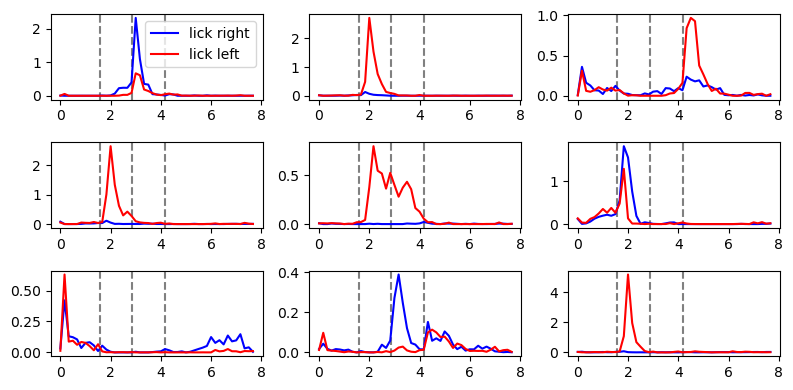

In [8]:
plt.figure(figsize=(8,4))
for ci in range(9):
    plt.subplot(3,3,ci+1)
    plt.axvline(tsample, color='gray', linestyle='--')
    plt.axvline(tdelay, color='gray', linestyle='--')
    plt.axvline(tresponse, color='gray', linestyle='--')
    plt.plot(tvec, opto_1R[ci], c='b', label='lick right')
    plt.plot(tvec, opto_1L[ci], c='r', label='lick left')
    if ci == 0:
        plt.legend()
plt.tight_layout()

## Project population activity to CD

In [9]:
# project population activity to CD. Use only the test trials
opto_1R_testtrials = opto_1R_alltrials[:,:,ntrain_trials_1R:]
opto_1L_testtrials = opto_1L_alltrials[:,:,ntrain_trials_1L:]
opto_2R_testtrials = opto_2R_alltrials[:,:,ntrain_trials_2R:]
opto_2L_testtrials = opto_2L_alltrials[:,:,ntrain_trials_2L:]

proj_1R_CD1 = np.tensordot(CD_sess1_population, opto_1R_testtrials, axes=(0,0))
proj_1L_CD1 = np.tensordot(CD_sess1_population, opto_1L_testtrials, axes=(0,0))
proj_2R_CD2 = np.tensordot(CD_sess2_population, opto_2R_testtrials, axes=(0,0))
proj_2L_CD2 = np.tensordot(CD_sess2_population, opto_2L_testtrials, axes=(0,0))

proj_1R_CD2 = np.tensordot(CD_sess2_population, opto_1R_testtrials, axes=(0,0))
proj_1L_CD2 = np.tensordot(CD_sess2_population, opto_1L_testtrials, axes=(0,0))
proj_2R_CD1 = np.tensordot(CD_sess1_population, opto_2R_testtrials, axes=(0,0))
proj_2L_CD1 = np.tensordot(CD_sess1_population, opto_2L_testtrials, axes=(0,0))

print(proj_1R_CD1.shape, proj_1L_CD1.shape, proj_2R_CD2.shape, proj_2L_CD2.shape)


(47, 60) (47, 54) (47, 57) (47, 48)


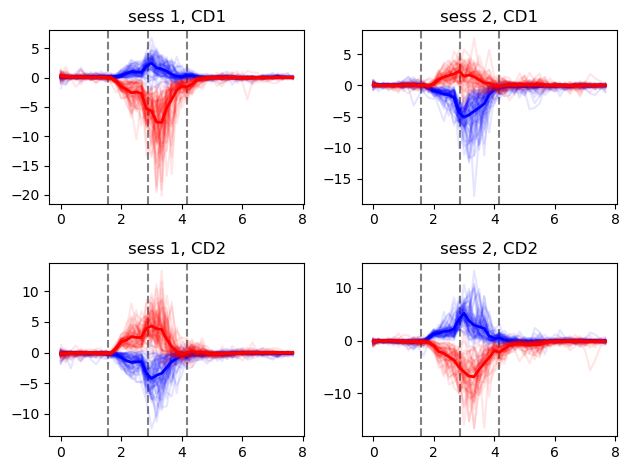

In [10]:
def plot_proj(tvec, proj_R, proj_L, ntest_trials_R, ntest_trials_L):
    plt.axvline(tsample, color='gray', linestyle='--')
    plt.axvline(tdelay, color='gray', linestyle='--')
    plt.axvline(tresponse, color='gray', linestyle='--')
    for trial in range(ntest_trials_R):
        plt.plot(tvec, proj_R[:,trial], c='b', alpha=0.1)
    plt.plot(tvec, np.mean(proj_R,axis=1), c='b', lw=2)
    for trial in range(ntest_trials_L):
        plt.plot(tvec, proj_L[:,trial], c='r', alpha=0.1)
    plt.plot(tvec, np.mean(proj_L,axis=1), c='r', lw=2)
    
ntest_trials_1R = ntrials_1R - ntrain_trials_1R
ntest_trials_1L = ntrials_1L - ntrain_trials_1L
ntest_trials_2R = ntrials_2R - ntrain_trials_2R
ntest_trials_2L = ntrials_2L - ntrain_trials_2L

plt.figure()
plt.subplot(2,2,1)
plt.title('sess 1, CD1')
proj_R = proj_1R_CD1
proj_L = proj_1L_CD1
plot_proj(tvec, proj_R, proj_L, ntest_trials_1R, ntest_trials_1L)

plt.subplot(2,2,2)
plt.title('sess 2, CD1')
proj_R = proj_2R_CD1
proj_L = proj_2L_CD1
plot_proj(tvec, proj_R, proj_L, ntest_trials_2R, ntest_trials_2L)

plt.subplot(2,2,3)
plt.title('sess 1, CD2')
proj_R = proj_1R_CD2
proj_L = proj_1L_CD2
plot_proj(tvec, proj_R, proj_L, ntest_trials_1R, ntest_trials_1L)

plt.subplot(2,2,4)
plt.title('sess 2, CD2')
proj_R = proj_2R_CD2
proj_L = proj_2L_CD2
plot_proj(tvec, proj_R, proj_L, ntest_trials_2R, ntest_trials_2L)

plt.tight_layout()


## Compare my and jh CD dot producdts

In [11]:
metadata = pd.read_csv(dirpath + 'EDF10d_info_2026_01_16.csv')
CDdotprod_python = pd.read_csv('CDdotprod_python_deconvolved.txt')
metadata['Merged_ID'] = (
    metadata['Mouse ID'].str.strip("'") + '_' + 
    metadata['FOV'].str.strip("'") + '_' + 
    metadata['Session1'].str.strip("'").str.replace("-", "_") + '_' + 
    metadata['Session2'].str.strip("'").str.replace("-", "_")
)
cols = ['Merged_ID'] + [c for c in metadata.columns if c != 'Merged_ID']
metadata = metadata[cols]
metadata = metadata.sort_values(by='Merged_ID')
metadata = metadata.reset_index(drop=True)
filtered_CDdotprod_python = CDdotprod_python[CDdotprod_python['ID'].isin(metadata['Merged_ID'])].reset_index(drop=True)
is_aligned = metadata['Merged_ID'].equals(filtered_CDdotprod_python['ID'])
print('is aligned: ', is_aligned)

is aligned:  True


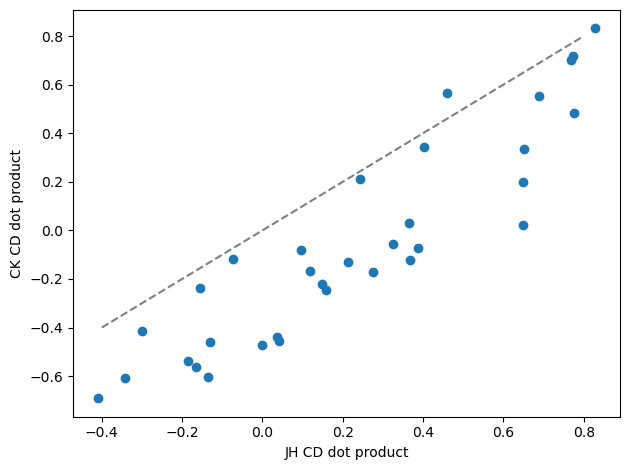

In [12]:
# filtered_CDdotprod_python.keys()
idline = np.arange(-0.4,0.8,0.1)
my_CDdotprod = filtered_CDdotprod_python['CDdotproduct']
jh_CDdotprod = metadata['CDdotproduct']
plt.figure()
plt.plot(idline, idline, color='gray', linestyle='--')
plt.scatter(jh_CDdotprod, my_CDdotprod)
plt.xlabel('JH CD dot product')
plt.ylabel('CK CD dot product')
plt.tight_layout()

# Spatial footprint

In [13]:
sf = data['spatial_footprints']

In [14]:
sf_sess1_CD = np.zeros((512,512,ncell))
sf_sess2_CD = np.zeros((512,512,ncell))
sf_sess1_SI = np.zeros((512,512,ncell))
sf_sess2_SI = np.zeros((512,512,ncell))
for cell in range(ncell):
    cix = sf[:,:,cell] > 0
    sf_sess1_CD[cix,cell] += 1
    sf_sess2_CD[cix,cell] += 1
    sf_sess1_CD[cix,cell] *= CD_sess1_population[cell]
    sf_sess2_CD[cix,cell] *= CD_sess2_population[cell]

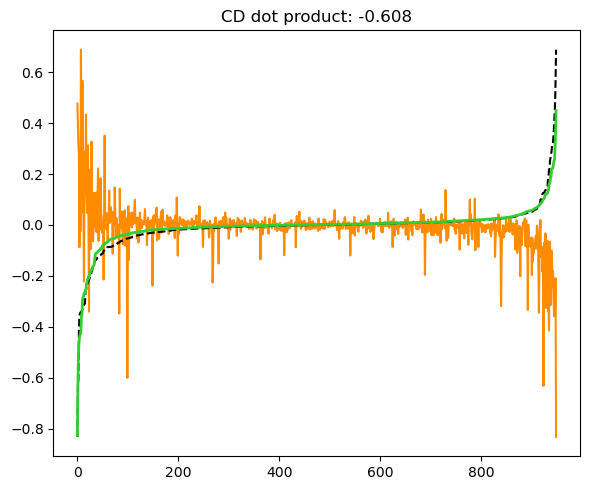

In [15]:
neuron_sorted_by_CD_sess1 = np.argsort(CD_sess1_population)
neuron_sorted_by_CD_sess2 = np.argsort(CD_sess2_population)
plt.figure(figsize=(6,5))
plt.plot(CD_sess2_population[neuron_sorted_by_CD_sess1], c='darkorange')
plt.plot(CD_sess2_population[neuron_sorted_by_CD_sess2], c='k', linestyle='--')
plt.plot(CD_sess1_population[neuron_sorted_by_CD_sess1], c='limegreen', lw=2)
plt.title('CD dot product: ' + str(np.round(CD_dotproduct,decimals=3)))
plt.tight_layout()


In [16]:
# select the top cells
frac_cell = 0.4
ncell_1R, ncell_1L = np.sum(CD_sess1_population>0), np.sum(CD_sess1_population<0)
ncell_2R, ncell_2L = np.sum(CD_sess2_population>0), np.sum(CD_sess2_population<0)
ncell_selected_1R, ncell_selected_1L = int(ncell_1R * frac_cell), int(ncell_1L * frac_cell)
ncell_selected_2R, ncell_selected_2L = int(ncell_2R * frac_cell), int(ncell_2L * frac_cell)

# all cells: 1R, 2R, 1L, 2L
all_cells_1R, all_cells_2R = np.where(CD_sess1_population > 0)[0], np.where(CD_sess2_population > 0)[0]
all_cells_1L, all_cells_2L = np.where(CD_sess1_population < 0)[0], np.where(CD_sess2_population < 0)[0]

# top cells: 1R, 2R, 1L, 2L
sorted_cells_sess1 = np.argsort(CD_sess1_population)
sorted_cells_sess2 = np.argsort(CD_sess2_population)
top_cells_1R = sorted_cells_sess1[-ncell_selected_1R:]
top_cells_2R = sorted_cells_sess2[-ncell_selected_2R:]
top_cells_1L = sorted_cells_sess1[:ncell_selected_1L]
top_cells_2L = sorted_cells_sess2[:ncell_selected_2L]

# cells shared by 1L, 2L
# cells not shared by 1L, 2L
mask_1L_in_2L      = np.isin(top_cells_1L, all_cells_2L)
mask_1L_notin_2L   = np.isin(top_cells_1L, all_cells_2L, invert=True)
mask_2L_notin_1L   = np.isin(top_cells_2L, all_cells_1L, invert=True)
shared_cells_1L_2L = top_cells_1L[mask_1L_in_2L]
nonshared_cells_1L = top_cells_1L[mask_1L_notin_2L]
nonshared_cells_2L = top_cells_2L[mask_2L_notin_1L]

sf_shared_1L_2L = sf_sess1_CD[:,:,shared_cells_1L_2L]
sf_nonshared_1L = sf_sess1_CD[:,:,nonshared_cells_1L]
sf_nonshared_2L = sf_sess2_CD[:,:,nonshared_cells_2L]

sf_top_1R = sf_sess1_CD[:,:,top_cells_1R]
sf_top_2R = sf_sess2_CD[:,:,top_cells_2R]
sf_top_1L = sf_sess1_CD[:,:,top_cells_1L]
sf_top_2L = sf_sess2_CD[:,:,top_cells_2L]
    

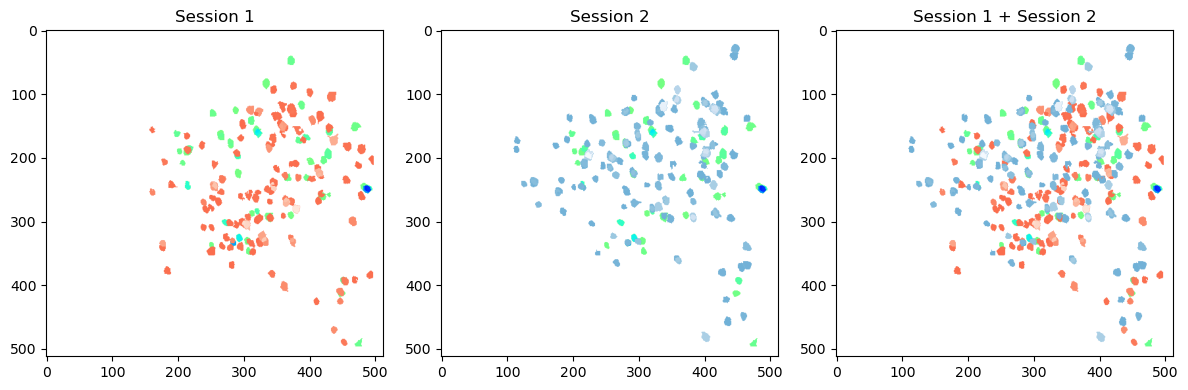

In [17]:
def create_plot_sf(cmap_type, sf, vlim):
    
    sf_sum = np.sum(sf, axis=2)
    vmin, vmax = -vlim, vlim    
    norm = mcolors.Normalize(vmin=vmin,vmax=vmax)
    cmap = plt.get_cmap(cmap_type)
    plot_sf = cmap(norm(sf_sum))
    plot_sf[sf_sum==0, 3] = 0
    return plot_sf
    
vlim = 1
plot_sf_shared_1L_2L = create_plot_sf('jet', sf_shared_1L_2L,vlim)
plot_sf_nonshared_1L = create_plot_sf('Reds',sf_nonshared_1L,vlim)
plot_sf_nonshared_2L = create_plot_sf('Blues', sf_nonshared_2L,vlim)    


plt.figure(figsize=(12,4))
plt.subplot(131)
plt.imshow(plot_sf_shared_1L_2L, aspect='auto')
plt.imshow(plot_sf_nonshared_1L, aspect='auto')
# plt.colorbar()
plt.title('Session 1')
plt.subplot(132)
plt.imshow(plot_sf_shared_1L_2L, aspect='auto')
plt.imshow(plot_sf_nonshared_2L, aspect='auto')
plt.title('Session 2')

plt.subplot(133)
plt.imshow(plot_sf_shared_1L_2L, aspect='auto')
plt.imshow(plot_sf_nonshared_1L, aspect='auto')
plt.imshow(plot_sf_nonshared_2L, aspect='auto')
plt.title('Session 1 + Session 2')
plt.tight_layout()

plt.savefig('figure/' + sessName + '.pdf')

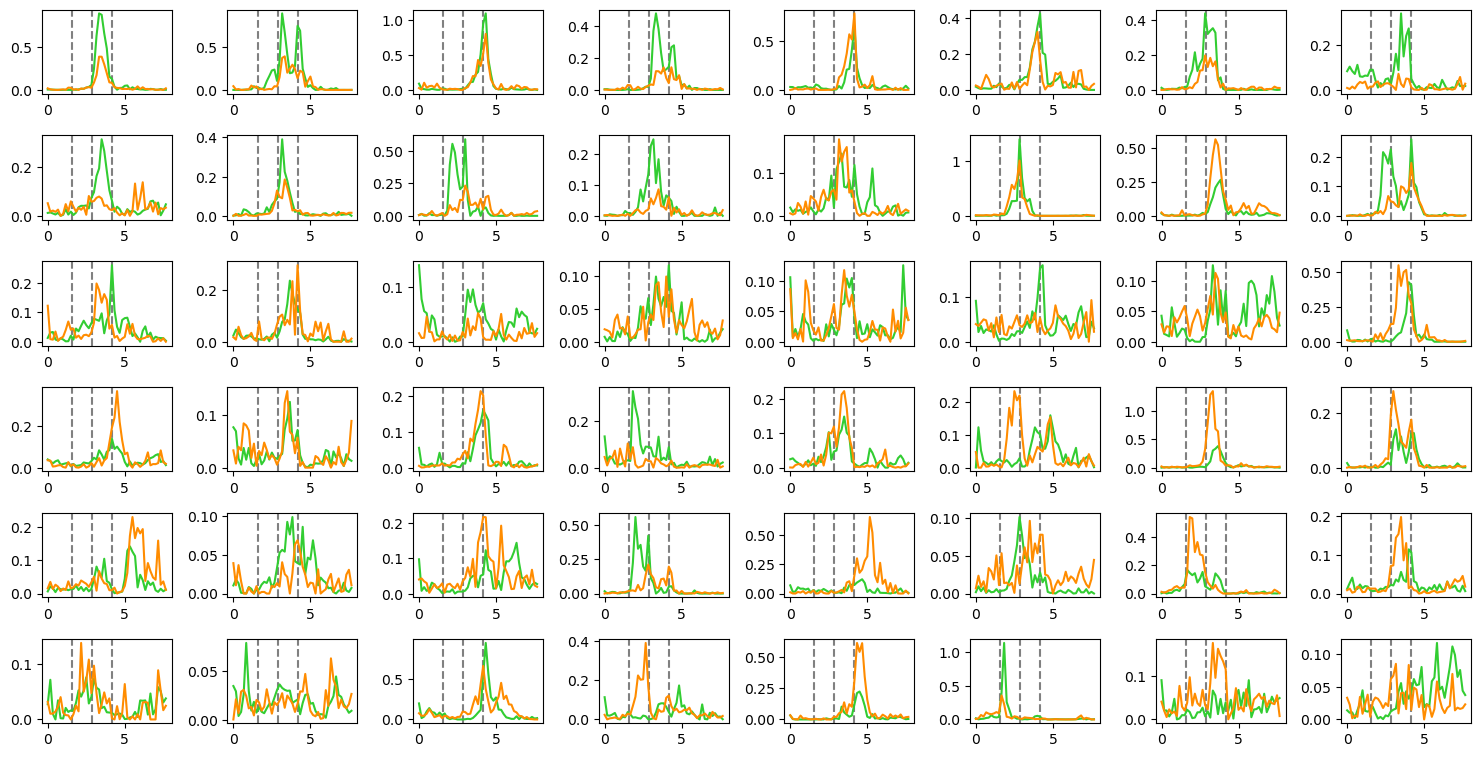

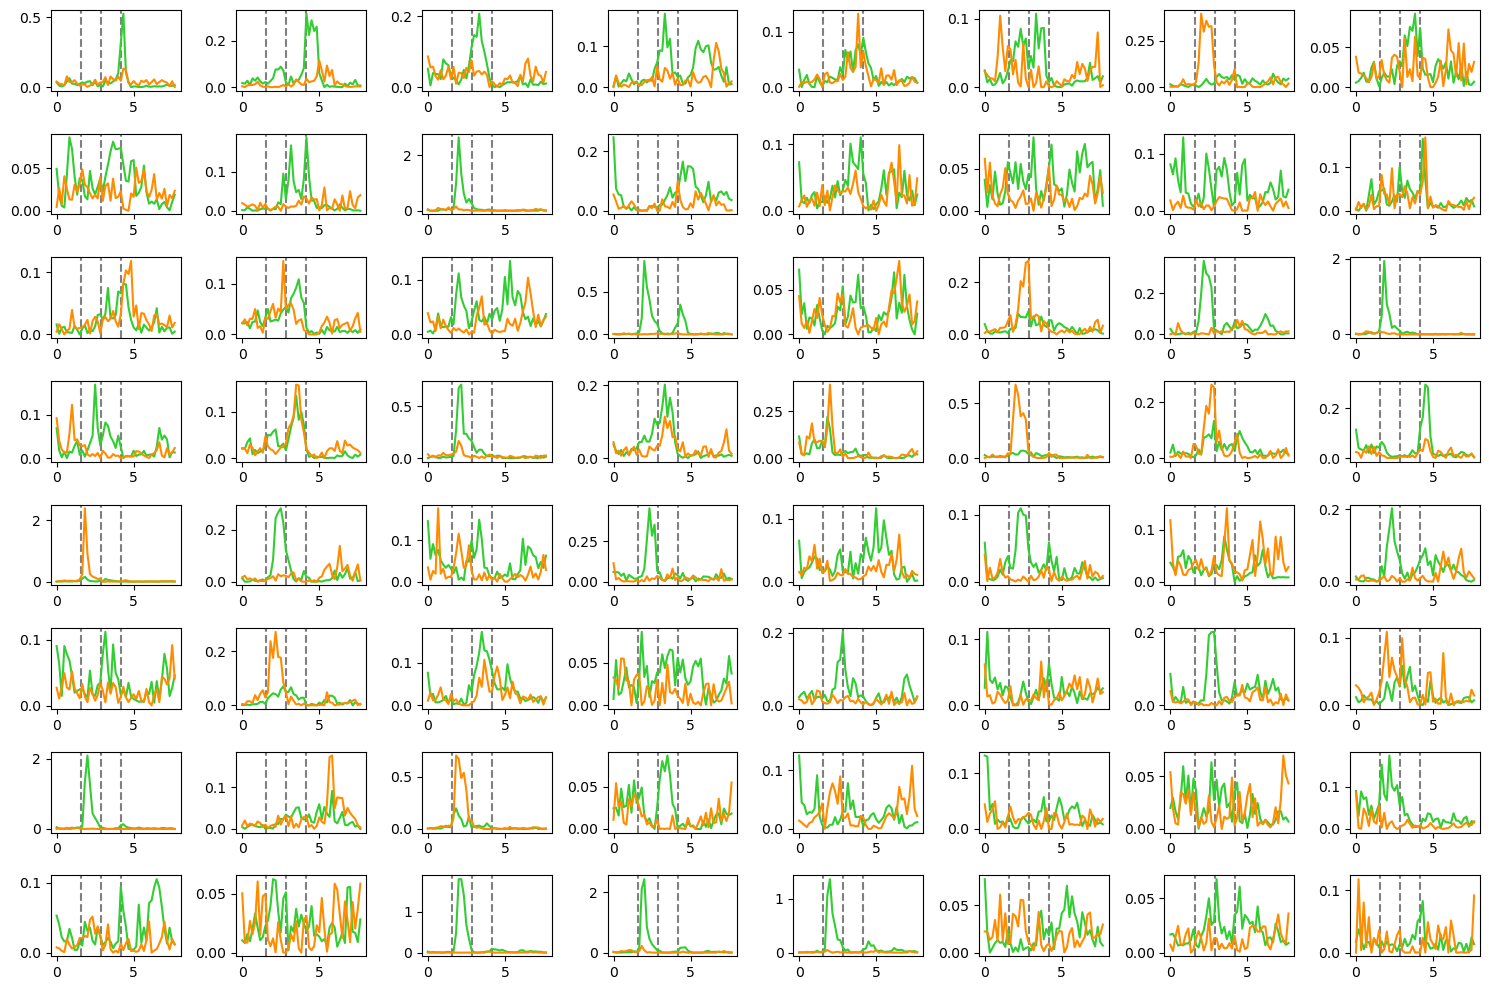

In [32]:
ncell_plot = 64
plot_shared_cells_1L_2L = shared_cells_1L_2L[-ncell_plot:]
plt.figure(figsize=(15,10))
for ix, ci in enumerate(plot_shared_cells_1L_2L):
    plt.subplot(8,8,ix+1)
    plt.axvline(tsample, color='gray', linestyle='--')
    plt.axvline(tdelay, color='gray', linestyle='--')
    plt.axvline(tresponse, color='gray', linestyle='--')    
    plt.plot(tvec, opto_1L[ci], color='limegreen')
    plt.plot(tvec, opto_2L[ci], color='darkorange')
plt.tight_layout()

plot_nonshared_cells_1L = nonshared_cells_1L[-ncell_plot:]
plt.figure(figsize=(15,10))
for ix, ci in enumerate(plot_nonshared_cells_1L):
    plt.subplot(8,8,ix+1)
    plt.axvline(tsample, color='gray', linestyle='--')
    plt.axvline(tdelay, color='gray', linestyle='--')
    plt.axvline(tresponse, color='gray', linestyle='--')    
    plt.plot(tvec, opto_1L[ci], color='limegreen')
    plt.plot(tvec, opto_2L[ci], color='darkorange')
plt.tight_layout()


In [34]:
n_shared_cell    = shared_cells_1L_2L.shape[0]
opto_1L_shared   = opto_1L[shared_cells_1L_2L,:]
opto_2L_shared   = opto_2L[shared_cells_1L_2L,:]

n_nonshared_cell_1L  = nonshared_cells_1L.shape[0]
opto_1L_nonshared_1L = opto_1L[nonshared_cells_1L,:]
opto_2L_nonshared_1L = opto_2L[nonshared_cells_1L,:]

n_nonshared_cell_2L  = nonshared_cells_2L.shape[0]
opto_1L_nonshared_2L = opto_1L[nonshared_cells_2L,:]
opto_2L_nonshared_2L = opto_2L[nonshared_cells_2L,:]

corr_shared_cell    = np.zeros(n_shared_cell)
mse_shared_cell    = np.zeros(n_shared_cell)
for ci in range(n_shared_cell):
    corr_shared_cell[ci] = np.corrcoef(opto_1L_shared[ci], opto_2L_shared[ci])[0,1]
    mse_shared_cell[ci] = np.std(opto_1L_shared[ci][tix_sample:tix_response] - opto_2L_shared[ci][tix_sample:tix_response])
    
corr_nonshared_cell_1L = np.zeros(n_nonshared_cell_1L)
mse_nonshared_cell_1L = np.zeros(n_nonshared_cell_1L)
for ci in range(n_nonshared_cell_1L):
    corr_nonshared_cell_1L[ci] = np.corrcoef(opto_1L_nonshared_1L[ci], opto_2L_nonshared_1L[ci])[0,1]
    mse_nonshared_cell_1L[ci] = np.std(opto_1L_nonshared_1L[ci][tix_sample:tix_response] - opto_2L_nonshared_1L[ci][tix_sample:tix_response])

corr_nonshared_cell_2L = np.zeros(n_nonshared_cell_2L)
mse_nonshared_cell_2L = np.zeros(n_nonshared_cell_2L)
for ci in range(n_nonshared_cell_2L):
    corr_nonshared_cell_2L[ci] = np.corrcoef(opto_1L_nonshared_2L[ci], opto_2L_nonshared_2L[ci])[0,1]
    mse_nonshared_cell_2L[ci] = np.std(opto_1L_nonshared_2L[ci][tix_sample:tix_response] - opto_2L_nonshared_2L[ci][tix_sample:tix_response]) 


In [25]:
mse_nonshared_cell_1L[0]

0.1655255885291246

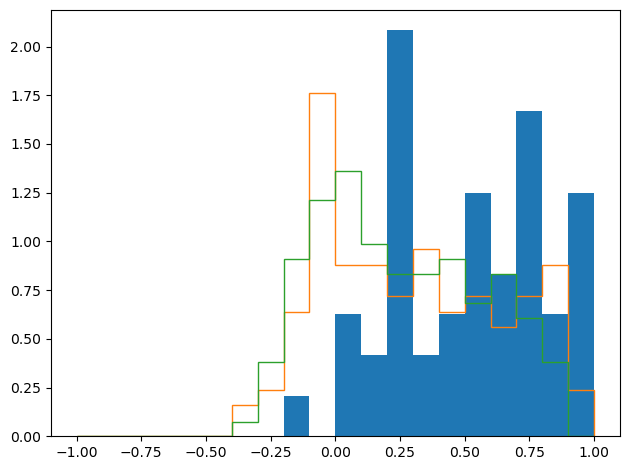

In [20]:
plt.figure()
plt.hist(corr_shared_cell, bins=20, range=(-1,1), histtype='bar', density=True)
plt.hist(corr_nonshared_cell_1L, bins=20, range=(-1,1), histtype='step', density=True)
plt.hist(corr_nonshared_cell_2L, bins=20, range=(-1,1), histtype='step', density=True)
plt.tight_layout()

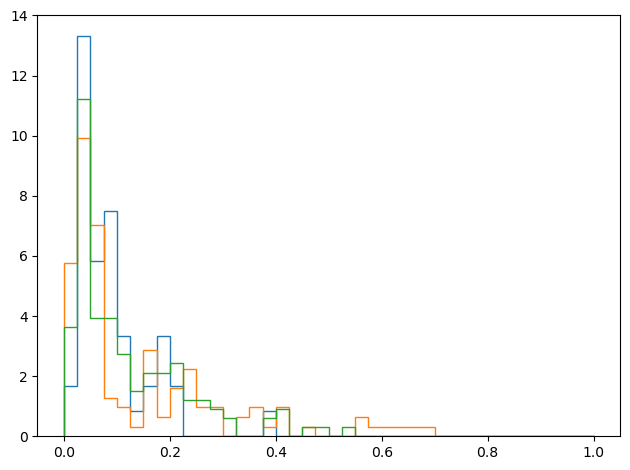

In [35]:
plt.figure()
plt.hist(mse_shared_cell, bins=40, range=(0,1), histtype='step', density=True)
plt.hist(mse_nonshared_cell_1L, bins=40, range=(0,1), histtype='step', density=True)
plt.hist(mse_nonshared_cell_2L, bins=40, range=(0,1), histtype='step', density=True)
plt.tight_layout()